# Part A - Data Loading and Preprocessing with Scikit-learn


# Task 1

In [3]:
import pandas as pd
df = pd.read_csv("hotel_bookings.csv")
display(df.head())

print("Shape:")
print(df.shape)

print("Dataset information:")
df.info()

print("Data types:")
print(df.dtypes)

print("Statistical summary:")
display(df.describe())

print("Class distribution:")
print(df["is_canceled"].value_counts())

print("Class distribution in percentage:")
print(df["is_canceled"].value_counts(normalize=True) * 100)

y = df["is_canceled"]

X = df.drop(columns=["is_canceled"])

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Shape:
(119390, 32)
Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null 

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Class distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64
Class distribution in percentage:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64
Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


# Task 2

Original shape:
(119390, 32)
Missing value table:


,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


Columns with more than 50% missing values:
['company']
Shape after removing leakage columns:
(119390, 30)
Numerical feature summary:


,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0


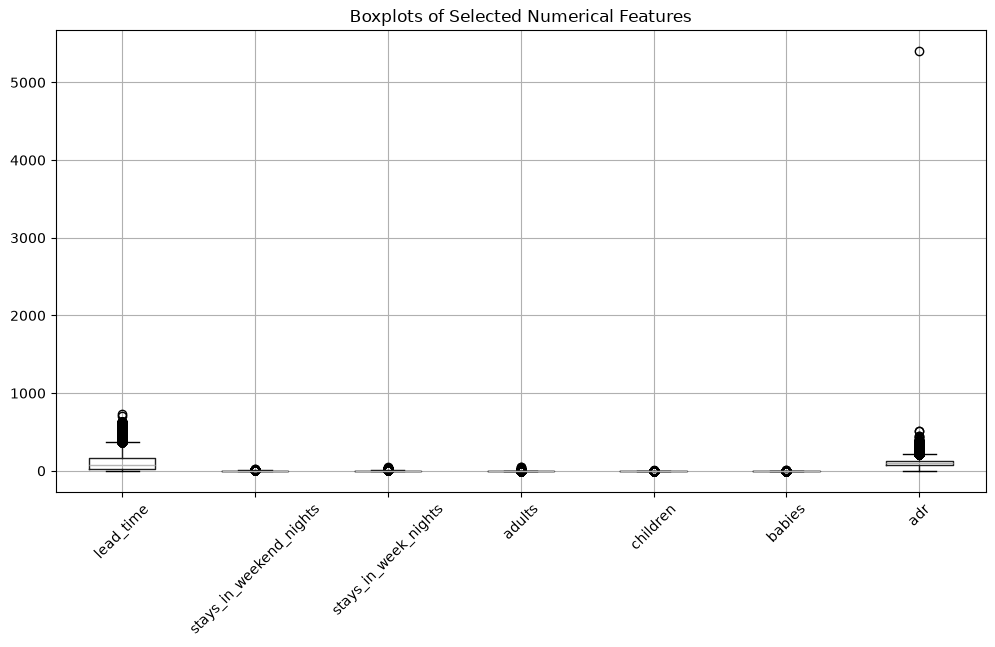

Potential outlier count for each feature:
lead_time                   3005
stays_in_weekend_nights      265
stays_in_week_nights        3354
adults                     29710
children                    8590
babies                       917
adr                         3793
dtype: int64
Potential outlier percentage for each feature:
lead_time                   2.516961
stays_in_weekend_nights     0.221962
stays_in_week_nights        2.809281
adults                     24.884831
children                    7.194907
babies                      0.768071
adr                         3.176983
dtype: float64
Lower bounds:
lead_time                 -195.000
stays_in_weekend_nights     -3.000
stays_in_week_nights        -2.000
adults                       2.000
children                     0.000
babies                       0.000
adr                        -15.775
dtype: float64
Upper bounds:
lead_time                  373.000
stays_in_weekend_nights      5.000
stays_in_week_nights         6.000


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hotel_bookings.csv")

print("Original shape:")
print(df.shape)

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

print("Missing value table:")
display(missing_table)

high_missing_cols = missing_table[
    missing_table["Missing Percentage"] > 50
].index.tolist()

print("Columns with more than 50% missing values:")
print(high_missing_cols)

df = df.drop(
    columns=["reservation_status", "reservation_status_date"]
)

print("Shape after removing leakage columns:")
print(df.shape)

selected_numerical_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "adr"
]

print("Numerical feature summary:")
display(df[selected_numerical_cols].describe().T)

df[selected_numerical_cols].boxplot(
    figsize=(12, 6),
    rot=45
)

plt.title("Boxplots of Selected Numerical Features")
plt.show()

Q1 = df[selected_numerical_cols].quantile(0.25)
Q3 = df[selected_numerical_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (df[selected_numerical_cols] < lower_bound) |
    (df[selected_numerical_cols] > upper_bound)
).sum()

print("Potential outlier count for each feature:")
print(outlier_counts)

outlier_percentage = (
    outlier_counts / len(df)
) * 100

print("Potential outlier percentage for each feature:")
print(outlier_percentage)

print("Lower bounds:")
print(lower_bound)

print("Upper bounds:")
print(upper_bound)

print("Final shape after Task 2:")
print(df.shape)

In [6]:
df = df.drop(columns=["company"])

print("Shape after removing high-missingness and leakage columns:")
print(df.shape)

selected_numerical_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "adr"
]

Q1 = df[selected_numerical_cols].quantile(0.25)
Q3 = df[selected_numerical_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (df[selected_numerical_cols] < lower_bound) |
    (df[selected_numerical_cols] > upper_bound)
).sum()

print("Potential outlier count:")
print(outlier_counts)

print("Rows removed:")
print(0)

print("Final shape:")
print(df.shape)

Shape after removing high-missingness and leakage columns:
(119390, 29)
Potential outlier count:
lead_time                   3005
stays_in_weekend_nights      265
stays_in_week_nights        3354
adults                     29710
children                    8590
babies                       917
adr                         3793
dtype: int64
Rows removed:
0
Final shape:
(119390, 29)


# Task 3

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

pipeline_A = Pipeline([
    ("preprocessor", preprocessor_A)
])

pipeline_B = Pipeline([
    ("preprocessor", preprocessor_B)
])

print("Pipeline A:")
print(pipeline_A)

print("\nPipeline B:")
print(pipeline_B)

X_train shape: (95512, 28)
X_test shape: (23878, 28)
y_train shape: (95512,)
y_test shape: (23878,)
Pipeline A:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                         

# Task 4

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

logistic_A.fit(X_train, y_train)

logistic_B.fit(X_train, y_train)

tree_A.fit(X_train, y_train)

tree_B.fit(X_train, y_train)

print("All four models trained successfully.")

All four models trained successfully.


# Task 5

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression - Pipeline A": logistic_A,
    "Logistic Regression - Pipeline B": logistic_B,
    "Decision Tree - Pipeline A": tree_A,
    "Decision Tree - Pipeline B": tree_B
}

results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

comparison_table = pd.DataFrame(results)

display(comparison_table)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Logistic Regression - Pipeline A,0.818923,0.818829,0.811269,0.665800,0.731371
1,Logistic Regression - Pipeline B,0.812568,0.813301,0.808292,0.650198,0.720677
2,Decision Tree - Pipeline A,0.996336,0.860206,0.808446,0.815941,0.812176
3,Decision Tree - Pipeline B,0.996336,0.860039,0.807808,0.816393,0.812078


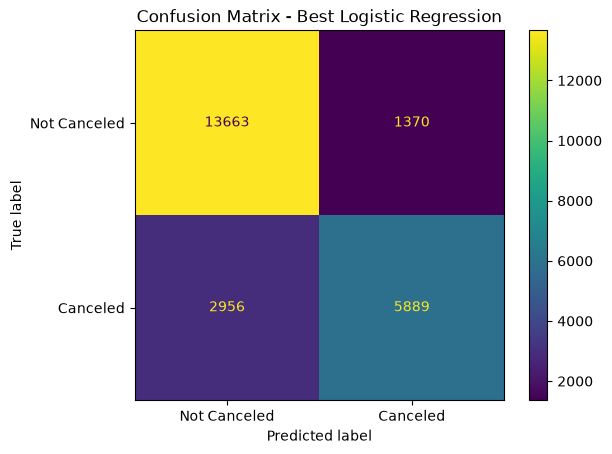

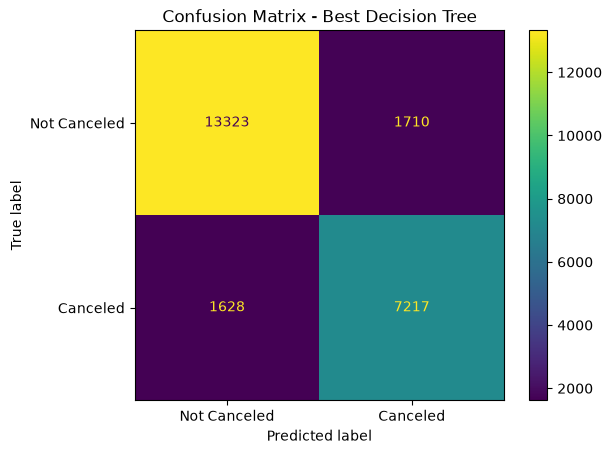

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred_logistic = logistic_A.predict(X_test)

cm_logistic = confusion_matrix(y_test, y_test_pred_logistic)

disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp_logistic.plot()
plt.title("Confusion Matrix - Best Logistic Regression")
plt.show()

y_test_pred_tree = tree_A.predict(X_test)

cm_tree = confusion_matrix(y_test, y_test_pred_tree)

disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp_tree.plot()
plt.title("Confusion Matrix - Best Decision Tree")
plt.show()

# Task 6

# 1. Which preprocessing-model combination gives the best overall result?
Training Accuracy = 0.996336
Testing Accuracy  = 0.860206
Precision          = 0.808446
Recall             = 0.815941
F1-Score           = 0.812176

Decision Tree + Pipeline A (StandardScaler) is the best overall combination. It has the highest testing accuracy and highest F1-score among the four experiments.


# 2. Does StandardScaler or MinMaxScaler affect Logistic Regression more?
|                  | StandardScaler | MinMaxScaler |
| ---------------- | -------------: | -----------: |
| Testing Accuracy |   **0.818829** |     0.813301 |
| Precision        |   **0.811269** |     0.808292 |
| Recall           |   **0.665800** |     0.650198 |
| F1               |   **0.731371** |     0.720677 |


StandardScaler performs slightly better than MinMaxScaler for Logistic Regression.

The difference is relatively small, so scaling does affect the results, but not dramatically.

# 3. Does scaling make a major difference for Decision Tree?

No.The difference is practically negligible.

This makes sense because Decision Trees make decisions using feature thresholds, so they generally don't depend on the numerical scale of features in the same way that distance/gradient-based models such as Logistic Regression can. Scaling had very little effect on Decision Tree performance.

# # Observations

Decision Tree models performed better than Logistic Regression models, achieving approximately 86.0% testing accuracy compared with approximately 81.9% for the best Logistic Regression model.
Decision Tree with StandardScaler produced the best overall result, with a testing accuracy of 86.02% and an F1-score of 0.8122.
StandardScaler performed slightly better than MinMaxScaler for Logistic Regression, with higher testing accuracy, precision, recall, and F1-score.
Scaling had almost no effect on Decision Tree performance, as the StandardScaler and MinMaxScaler versions produced nearly identical results.
The Decision Tree shows signs of overfitting, with training accuracy of approximately 99.63% compared with testing accuracy of approximately 86.02%, whereas Logistic Regression had very similar training and testing accuracy.

In [11]:
comparison_table

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Logistic Regression - Pipeline A,0.818923,0.818829,0.811269,0.665800,0.731371
1,Logistic Regression - Pipeline B,0.812568,0.813301,0.808292,0.650198,0.720677
2,Decision Tree - Pipeline A,0.996336,0.860206,0.808446,0.815941,0.812176
3,Decision Tree - Pipeline B,0.996336,0.860039,0.807808,0.816393,0.812078
